In [31]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

## Preparação dos dados do IPCA

Os valores do IPCA foram obtidos no terminal Bloomberg pelo ticker `BZPIIPCA Index`, utilizando o script `_aux/get_IPCA.py`. A Bloomberg disponibiliza uma observação por mês e associa o valor ao último dia do respectivo mês de referência. Essa data é apenas uma convenção da série e não representa o dia em que o IPCA foi efetivamente divulgado.

Para identificar quando cada valor passou a estar disponível, utilizamos as datas oficiais de divulgação do IBGE, coletadas pelo script `_aux/IPCA_dates.py`. As duas bases são combinadas pelo mês de referência, resultando em um DataFrame no qual cada valor do IPCA está associado à sua data exata de divulgação.


In [5]:
DATA_DIR = Path("_aux/data")

ipca_bloomberg = pd.read_csv(
    DATA_DIR / "ipca_bloomberg.csv",
    parse_dates=["data_bloomberg"],
)

ipca_ibge = pd.read_csv(
    DATA_DIR / "datas_divulgacao_ipca_ibge.csv",
    parse_dates=["data_divulgacao"],
)

ipca_bloomberg["periodo_referencia"] = (
    ipca_bloomberg["data_bloomberg"]
    .dt.to_period("M")
    .astype(str)
)

ipca_ibge["periodo_referencia"] = (
    ipca_ibge["periodo_referencia"]
    .astype(str)
    .str.strip()
)

ipca = ipca_bloomberg.merge(
    ipca_ibge,
    on="periodo_referencia",
    how="left",
    validate="one_to_one",
)

periodos_sem_data = ipca.loc[
    ipca["data_divulgacao"].isna(),
    "periodo_referencia",
].tolist()

if periodos_sem_data:
    raise ValueError(
        "Não foram encontradas datas de divulgação para: "
        + ", ".join(periodos_sem_data)
    )

ipca = (
    ipca[
        [
            "data_divulgacao",
            "periodo_referencia",
            "ipca_index",
        ]
    ]
    .rename(
        columns={
            "data_divulgacao": "date",
        }
    )
    .sort_values("date")
    .reset_index(drop=True)
)

ipca

,date,periodo_referencia,ipca_index
0,2017-05-10,2017-04,4828.44
1,2017-06-09,2017-05,4843.41
2,2017-07-07,2017-06,4832.27
3,2017-08-09,2017-07,4843.87
4,2017-09-06,2017-08,4853.07
...,...,...,...
106,2026-03-12,2026-02,7479.71
107,2026-04-10,2026-03,7545.53
108,2026-05-12,2026-04,7596.09
109,2026-06-12,2026-05,7640.15


## Comparação entre CDI e IPCA

Os dados do CDI foram obtidos na Bloomberg pelo ticker `IDIX9 Index`. Essa série representa um índice acumulado que incorpora diariamente o rendimento da Taxa DI, sendo adequada para acompanhar o desempenho de um investimento remunerado a 100% do CDI.

Os dados do IPCA foram obtidos pelo ticker `BZPIIPCA Index`, com as datas de divulgação ajustadas a partir do calendário oficial do IBGE.

Como os índices CDI e IPCA possuem bases numéricas diferentes, ambos são normalizados para 100 na primeira data em que os dois estão disponíveis. O IPCA é mantido constante entre duas divulgações, de modo que cada novo valor somente aparece na série a partir do dia em que foi oficialmente publicado.


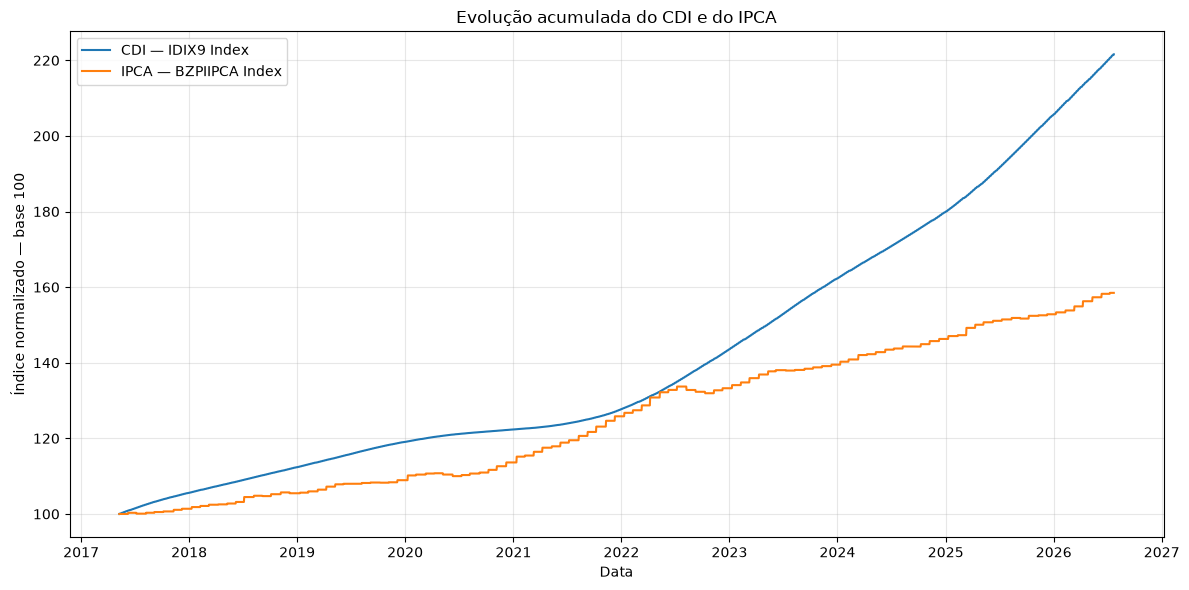

In [8]:
# Carrega os dados do CDI.
cdi = pd.read_csv(
    DATA_DIR / "cdi_bloomberg.csv",
    parse_dates=["data"],
)

cdi = (
    cdi[
        [
            "data",
            "cdi_index",
        ]
    ]
    .dropna()
    .sort_values("data")
    .reset_index(drop=True)
)


# Seleciona os dados do IPCA preparados anteriormente.
ipca_para_comparacao = (
    ipca[
        [
            "date",
            "ipca_index",
        ]
    ]
    .rename(
        columns={
            "date": "data",
        }
    )
    .dropna()
    .sort_values("data")
    .reset_index(drop=True)
)


# Para cada dia do CDI, associa o último IPCA que já havia
# sido oficialmente divulgado naquela data.
comparacao = pd.merge_asof(
    cdi,
    ipca_para_comparacao,
    on="data",
    direction="backward",
)


# Remove os dias anteriores à primeira divulgação disponível
# do IPCA.
comparacao = (
    comparacao
    .dropna(subset=["ipca_index"])
    .reset_index(drop=True)
)


# Normaliza as duas séries para base 100.
comparacao["cdi_base_100"] = (
    comparacao["cdi_index"]
    / comparacao["cdi_index"].iloc[0]
    * 100
)

comparacao["ipca_base_100"] = (
    comparacao["ipca_index"]
    / comparacao["ipca_index"].iloc[0]
    * 100
)


# Gráfico.
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    comparacao["data"],
    comparacao["cdi_base_100"],
    label="CDI — IDIX9 Index",
)

ax.plot(
    comparacao["data"],
    comparacao["ipca_base_100"],
    label="IPCA — BZPIIPCA Index",
)

ax.set_title("Evolução acumulada do CDI e do IPCA")
ax.set_xlabel("Data")
ax.set_ylabel("Índice normalizado — base 100")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Índices futuros de milho e boi gordo

Para representar o investimento em futuros de commodities no Brasil, utilizamos os índices `IFMILHO` e `IFBOI`, disponibilizados pela B3.

O `IFMILHO` acompanha uma carteira teórica composta por contratos futuros de milho (`CCM`), utilizando o primeiro vencimento e realizando rolagens bimestrais. O `IFBOI` acompanha contratos futuros de boi gordo (`BGI`), também utilizando o primeiro vencimento, mas com rolagens mensais.

Durante o período de rolagem, a posição é transferida gradualmente do primeiro para o segundo vencimento. Os dois índices são classificados pela B3 como índices de retorno total, incorporando tanto a variação dos contratos futuros quanto o rendimento do DI sobre o caixa utilizado como garantia.

Como o DI já está incluído nos índices, não adicionamos novamente o retorno do CDI aos retornos de milho e boi. O CDI será utilizado separadamente como benchmark de retorno nominal de baixo risco.

Os arquivos possuem várias planilhas, mas utilizamos a planilha `Indice Resumido`, que contém apenas a data de referência e o valor diário do índice.

In [10]:
def carregar_indice_b3(caminho, nome_indice):
    dados = pd.read_excel(
        caminho,
        sheet_name="Indice Resumido",
    )

    dados = dados.rename(
        columns={
            "Data_Referencia": "data",
            "Indice": nome_indice,
        }
    )

    dados = dados[
        [
            "data",
            nome_indice,
        ]
    ].copy()

    # Em algumas versões do pandas, datas do Excel podem ser
    # importadas como números seriais.
    if pd.api.types.is_numeric_dtype(dados["data"]):
        dados["data"] = pd.to_datetime(
            dados["data"],
            unit="D",
            origin="1899-12-30",
        )
    else:
        dados["data"] = pd.to_datetime(
            dados["data"],
            errors="coerce",
            dayfirst=True,
        )

    dados[nome_indice] = pd.to_numeric(
        dados[nome_indice],
        errors="coerce",
    )

    dados = (
        dados
        .dropna(subset=["data", nome_indice])
        .drop_duplicates(subset="data")
        .sort_values("data")
        .reset_index(drop=True)
    )

    return dados


ifboi = carregar_indice_b3(
    DATA_DIR / "IFBOI.xlsx",
    "ifboi_index",
)

ifmilho = carregar_indice_b3(
    DATA_DIR / "IFMILHO.xlsx",
    "ifmilho_index",
)

print("IFBOI")
print(ifboi.head())
print(ifboi.tail())
print()

print("IFMILHO")
print(ifmilho.head())
print(ifmilho.tail())

IFBOI
        data  ifboi_index
0 2017-04-24  1000.000000
1 2017-04-25   997.838860
2 2017-04-26   997.296415
3 2017-04-27   998.154509
4 2017-04-28  1000.344819
           data  ifboi_index
2286 2026-07-08  3655.473560
2287 2026-07-09  3670.722870
2288 2026-07-10  3670.428505
2289 2026-07-13  3669.020835
2290 2026-07-14  3707.104331

IFMILHO
        data  ifmilho_index
0 2017-04-24    1000.000000
1 2017-04-25    1005.708860
2 2017-04-26     992.364381
3 2017-04-27     996.663303
4 2017-04-28     993.896765
           data  ifmilho_index
2286 2026-07-08    2752.372401
2287 2026-07-09    2731.967514
2288 2026-07-10    2728.139531
2289 2026-07-13    2747.395801
2290 2026-07-14    2736.680573


In [12]:
commodities_diario = ifboi.merge(
    ifmilho,
    on="data",
    how="inner",
    validate="one_to_one",
)

commodities_diario

,data,ifboi_index,ifmilho_index
0,2017-04-24,1000.000000,1000.000000
1,2017-04-25,997.838860,1005.708860
2,2017-04-26,997.296415,992.364381
3,2017-04-27,998.154509,996.663303
4,2017-04-28,1000.344819,993.896765
...,...,...,...
2286,2026-07-08,3655.473560,2752.372401
2287,2026-07-09,3670.722870,2731.967514
2288,2026-07-10,3670.428505,2728.139531
2289,2026-07-13,3669.020835,2747.395801


In [13]:
commodities_mensal = (
    commodities_diario
    .set_index("data")
    .resample("ME")
    .last()
    .dropna()
    .reset_index()
)

commodities_mensal["retorno_ifboi"] = (
    commodities_mensal["ifboi_index"]
    .pct_change()
)

commodities_mensal["retorno_ifmilho"] = (
    commodities_mensal["ifmilho_index"]
    .pct_change()
)

commodities_mensal["mes"] = (
    commodities_mensal["data"]
    .dt.to_period("M")
)

commodities_mensal.head()

,data,ifboi_index,ifmilho_index,retorno_ifboi,retorno_ifmilho,mes
0,2017-04-30,1000.344819,993.896765,NaN,NaN,2017-04
1,2017-05-31,977.509304,959.087661,-0.022828,-0.035023,2017-05
2,2017-06-30,979.357474,928.675796,0.001891,-0.031709,2017-06
3,2017-07-31,1014.233514,928.388480,0.035611,-0.000309,2017-07
4,2017-08-31,1107.003107,988.425576,0.091468,0.064668,2017-08


In [14]:
ipca_mensal = ipca[
    [
        "periodo_referencia",
        "ipca_index",
    ]
].copy()

ipca_mensal["mes"] = pd.PeriodIndex(
    ipca_mensal["periodo_referencia"],
    freq="M",
)

ipca_mensal = (
    ipca_mensal
    .sort_values("mes")
    .drop_duplicates(subset="mes")
    .reset_index(drop=True)
)

ipca_mensal["inflacao_mensal"] = (
    ipca_mensal["ipca_index"]
    .pct_change()
)

ipca_mensal.head()

,periodo_referencia,ipca_index,mes,inflacao_mensal
0,2017-04,4828.44,2017-04,NaN
1,2017-05,4843.41,2017-05,0.003100
2,2017-06,4832.27,2017-06,-0.002300
3,2017-07,4843.87,2017-07,0.002401
4,2017-08,4853.07,2017-08,0.001899


In [15]:
base_mensal = commodities_mensal.merge(
    ipca_mensal[
        [
            "mes",
            "ipca_index",
            "inflacao_mensal",
        ]
    ],
    on="mes",
    how="inner",
    validate="one_to_one",
)

base_mensal = base_mensal[
    [
        "mes",
        "data",
        "ipca_index",
        "inflacao_mensal",
        "ifboi_index",
        "retorno_ifboi",
        "ifmilho_index",
        "retorno_ifmilho",
    ]
]

base_mensal.head()

,mes,data,ipca_index,inflacao_mensal,ifboi_index,retorno_ifboi,ifmilho_index,retorno_ifmilho
0,2017-04,2017-04-30,4828.44,NaN,1000.344819,NaN,993.896765,NaN
1,2017-05,2017-05-31,4843.41,0.003100,977.509304,-0.022828,959.087661,-0.035023
2,2017-06,2017-06-30,4832.27,-0.002300,979.357474,0.001891,928.675796,-0.031709
3,2017-07,2017-07-31,4843.87,0.002401,1014.233514,0.035611,928.388480,-0.000309
4,2017-08,2017-08-31,4853.07,0.001899,1107.003107,0.091468,988.425576,0.064668


In [16]:
base_mensal_modelo = (
    base_mensal
    .dropna(
        subset=[
            "inflacao_mensal",
            "retorno_ifboi",
            "retorno_ifmilho",
        ]
    )
    .reset_index(drop=True)
)

base_mensal_modelo.head()

,mes,data,ipca_index,inflacao_mensal,ifboi_index,retorno_ifboi,ifmilho_index,retorno_ifmilho
0,2017-05,2017-05-31,4843.41,0.003100,977.509304,-0.022828,959.087661,-0.035023
1,2017-06,2017-06-30,4832.27,-0.002300,979.357474,0.001891,928.675796,-0.031709
2,2017-07,2017-07-31,4843.87,0.002401,1014.233514,0.035611,928.388480,-0.000309
3,2017-08,2017-08-31,4853.07,0.001899,1107.003107,0.091468,988.425576,0.064668
4,2017-09,2017-09-30,4860.83,0.001599,1127.959271,0.018931,1050.151084,0.062448


## Incorporação do CDI

O `IFBOI` e o `IFMILHO` são índices de retorno total e já incorporam o rendimento do DI sobre o caixa dado como garantia. Portanto, o CDI não é adicionado novamente aos retornos desses índices.

A série `IDIX9 Index` é mantida separadamente como um benchmark nominal de baixo risco. Posteriormente, ela será utilizada para avaliar o custo de incluir futuros de commodities em uma carteira originalmente investida em CDI.

In [17]:
cdi = pd.read_csv(
    DATA_DIR / "cdi_bloomberg.csv",
    parse_dates=["data"],
)

cdi_mensal = (
    cdi[
        [
            "data",
            "cdi_index",
        ]
    ]
    .dropna()
    .sort_values("data")
    .set_index("data")
    .resample("ME")
    .last()
    .dropna()
    .reset_index()
)

cdi_mensal["mes"] = (
    cdi_mensal["data"]
    .dt.to_period("M")
)

cdi_mensal["retorno_cdi"] = (
    cdi_mensal["cdi_index"]
    .pct_change()
)

base_mensal = base_mensal.merge(
    cdi_mensal[
        [
            "mes",
            "cdi_index",
            "retorno_cdi",
        ]
    ],
    on="mes",
    how="inner",
    validate="one_to_one",
)

base_mensal_modelo = (
    base_mensal
    .dropna(
        subset=[
            "inflacao_mensal",
            "retorno_ifboi",
            "retorno_ifmilho",
            "retorno_cdi",
        ]
    )
    .sort_values("mes")
    .reset_index(drop=True)
)

base_mensal_modelo.head()

,mes,data,ipca_index,inflacao_mensal,ifboi_index,retorno_ifboi,ifmilho_index,retorno_ifmilho,cdi_index,retorno_cdi
0,2017-05,2017-05-31,4843.41,0.003100,977.509304,-0.022828,959.087661,-0.035023,236227.7,0.009256
1,2017-06,2017-06-30,4832.27,-0.002300,979.357474,0.001891,928.675796,-0.031709,238145.1,0.008117
2,2017-07,2017-07-31,4843.87,0.002401,1014.233514,0.035611,928.388480,-0.000309,240052.1,0.008008
3,2017-08,2017-08-31,4853.07,0.001899,1107.003107,0.091468,988.425576,0.064668,241976.0,0.008015
4,2017-09,2017-09-30,4860.83,0.001599,1127.959271,0.018931,1050.151084,0.062448,243528.1,0.006414


In [20]:
variaveis_pct = (
    base_mensal_modelo[
        [
            "inflacao_mensal",
            "retorno_ifboi",
            "retorno_ifmilho",
            "retorno_cdi",
        ]
    ]
    * 100
)

variaveis_pct = variaveis_pct.rename(
    columns={
        "inflacao_mensal": "IPCA",
        "retorno_ifboi": "IFBOI",
        "retorno_ifmilho": "IFMILHO",
        "retorno_cdi": "CDI",
    }
)


def estatisticas_descritivas(serie):
    return pd.Series(
        {
            "media": serie.mean(),
            "desvio_padrao": serie.std(ddof=1),
            "assimetria": serie.skew(),
            # pandas retorna excesso de curtose;
            # somamos 3 para obter a curtose convencional.
            "curtose": serie.kurt() + 3,
            "q_1_pct": serie.quantile(0.01),
            "q_5_pct": serie.quantile(0.05),
            "q_10_pct": serie.quantile(0.10),
            "mediana": serie.quantile(0.50),
            "q_90_pct": serie.quantile(0.90),
            "q_95_pct": serie.quantile(0.95),
            "q_99_pct": serie.quantile(0.99),
        }
    )


tabela_descritiva = (
    variaveis_pct
    .apply(estatisticas_descritivas)
    .T
    .round(4)
)

tabela_descritiva

,media,desvio_padrao,assimetria,curtose,q_1_pct,q_5_pct,q_10_pct,mediana,q_90_pct,q_95_pct,q_99_pct
IPCA,0.4203,0.3954,0.3403,3.6569,-0.3782,-0.2210,-0.0220,0.3800,0.9320,1.1555,1.3464
IFBOI,1.3262,5.4680,1.1833,6.8174,-10.4254,-5.5681,-3.6176,0.4763,7.2356,9.3480,20.3081
IFMILHO,1.1831,7.2493,0.3705,4.0636,-15.3564,-9.4547,-6.8552,0.6907,9.2816,11.7371,19.9606
CDI,0.7215,0.3296,-0.1595,1.7929,0.1502,0.1587,0.2364,0.7898,1.1372,1.1747,1.2707


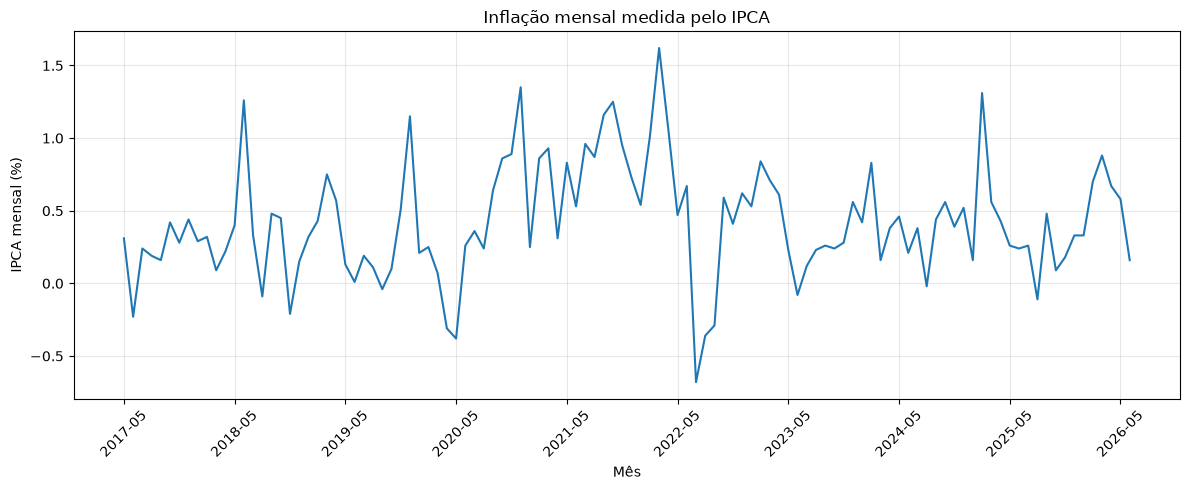

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    base_mensal_modelo["mes"].astype(str),
    base_mensal_modelo["inflacao_mensal"] * 100,
)

plt.title("Inflação mensal medida pelo IPCA")
plt.xlabel("Mês")
plt.ylabel("IPCA mensal (%)")

plt.xticks(
    ticks=range(
        0,
        len(base_mensal_modelo),
        12,
    ),
    labels=base_mensal_modelo[
        "mes"
    ].astype(str).iloc[::12],
    rotation=45,
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

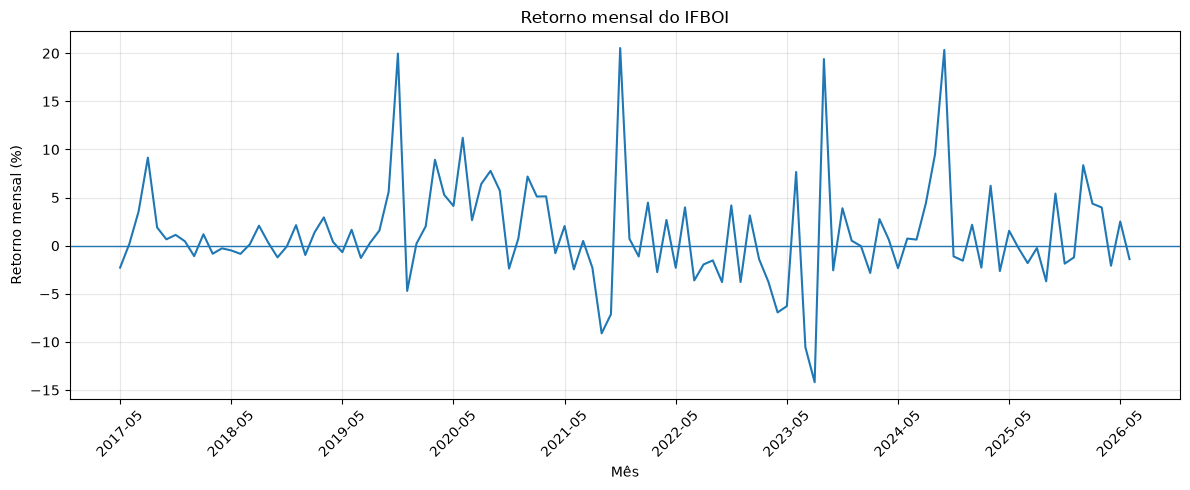

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    base_mensal_modelo["mes"].astype(str),
    base_mensal_modelo["retorno_ifboi"] * 100,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title("Retorno mensal do IFBOI")
plt.xlabel("Mês")
plt.ylabel("Retorno mensal (%)")

plt.xticks(
    ticks=range(
        0,
        len(base_mensal_modelo),
        12,
    ),
    labels=base_mensal_modelo[
        "mes"
    ].astype(str).iloc[::12],
    rotation=45,
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

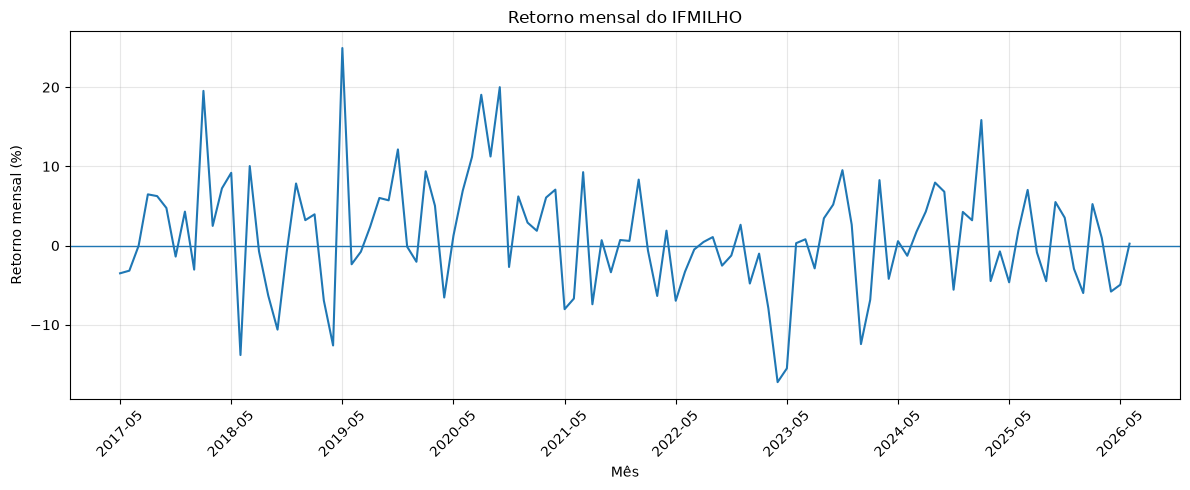

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    base_mensal_modelo["mes"].astype(str),
    base_mensal_modelo["retorno_ifmilho"] * 100,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title("Retorno mensal do IFMILHO")
plt.xlabel("Mês")
plt.ylabel("Retorno mensal (%)")

plt.xticks(
    ticks=range(
        0,
        len(base_mensal_modelo),
        12,
    ),
    labels=base_mensal_modelo[
        "mes"
    ].astype(str).iloc[::12],
    rotation=45,
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
matriz_correlacao = (
    base_mensal_modelo[
        [
            "inflacao_mensal",
            "retorno_ifboi",
            "retorno_ifmilho",
            "retorno_cdi",
        ]
    ]
    .corr()
    .rename(
        index={
            "inflacao_mensal": "IPCA",
            "retorno_ifboi": "IFBOI",
            "retorno_ifmilho": "IFMILHO",
            "retorno_cdi": "CDI",
        },
        columns={
            "inflacao_mensal": "IPCA",
            "retorno_ifboi": "IFBOI",
            "retorno_ifmilho": "IFMILHO",
            "retorno_cdi": "CDI",
        },
    )
)

matriz_correlacao.round(4)

,IPCA,IFBOI,IFMILHO,CDI
IPCA,1.0000,-0.0585,-0.1025,-0.1448
IFBOI,-0.0585,1.0000,0.3188,-0.1964
IFMILHO,-0.1025,0.3188,1.0000,-0.2929
CDI,-0.1448,-0.1964,-0.2929,1.0000


In [25]:
correlacoes_ipca = pd.DataFrame(
    {
        "ativo": [
            "IFBOI",
            "IFMILHO",
            "CDI",
        ],
        "correlacao_com_ipca": [
            base_mensal_modelo[
                "retorno_ifboi"
            ].corr(
                base_mensal_modelo[
                    "inflacao_mensal"
                ]
            ),
            base_mensal_modelo[
                "retorno_ifmilho"
            ].corr(
                base_mensal_modelo[
                    "inflacao_mensal"
                ]
            ),
            base_mensal_modelo[
                "retorno_cdi"
            ].corr(
                base_mensal_modelo[
                    "inflacao_mensal"
                ]
            ),
        ],
    }
)

correlacoes_ipca.round(4)

,ativo,correlacao_com_ipca
0,IFBOI,-0.0585
1,IFMILHO,-0.1025
2,CDI,-0.1448


In [27]:
import statsmodels.api as sm


def regressao_fisher(
    dados,
    coluna_retorno,
    nome_ativo,
):
    y = dados[coluna_retorno] * 100

    X = pd.DataFrame(
        {
            "inflacao": (
                dados["inflacao_mensal"]
                * 100
            )
        }
    )

    X = sm.add_constant(X)

    modelo = sm.OLS(
        y,
        X,
        missing="drop",
    ).fit(
        cov_type="HC0"
    )

    intervalo = modelo.conf_int().loc[
        "inflacao"
    ]

    return {
        "ativo": nome_ativo,
        "alpha": modelo.params["const"],
        "beta_fisher": modelo.params["inflacao"],
        "erro_padrao_robusto": modelo.bse["inflacao"],
        "estatistica_t": modelo.tvalues["inflacao"],
        "p_valor": modelo.pvalues["inflacao"],
        "limite_inferior_95": intervalo.iloc[0],
        "limite_superior_95": intervalo.iloc[1],
        "r_quadrado": modelo.rsquared,
    }


resultados_fisher = pd.DataFrame(
    [
        regressao_fisher(
            base_mensal_modelo,
            "retorno_ifboi",
            "IFBOI",
        ),
        regressao_fisher(
            base_mensal_modelo,
            "retorno_ifmilho",
            "IFMILHO",
        ),
    ]
)

resultados_fisher.round(4)

,ativo,alpha,beta_fisher,erro_padrao_robusto,estatistica_t,p_valor,limite_inferior_95,limite_superior_95,r_quadrado
0,IFBOI,1.6660,-0.8086,1.2096,-0.6685,0.5038,-3.1794,1.5621,0.0034
1,IFMILHO,1.9732,-1.8799,1.6668,-1.1279,0.2594,-5.1468,1.3869,0.0105


## Evolução acumulada do IPCA, CDI, IFBOI e IFMILHO

Para comparar as quatro séries, normalizamos seus níveis para 100 na primeira observação comum da amostra. Essa transformação preserva as variações percentuais de cada índice, eliminando as diferenças entre suas bases numéricas originais.

A linha do IPCA representa a evolução acumulada do nível geral de preços. O CDI representa o retorno acumulado do benchmark nominal de baixo risco. O IFBOI e o IFMILHO representam o desempenho acumulado dos índices de retorno total de futuros de boi gordo e milho, respectivamente.

Como o IFBOI e o IFMILHO já incorporam o rendimento do DI sobre o caixa utilizado como garantia, o CDI não é adicionado novamente aos índices de commodities. Ele é apresentado apenas como benchmark separado.

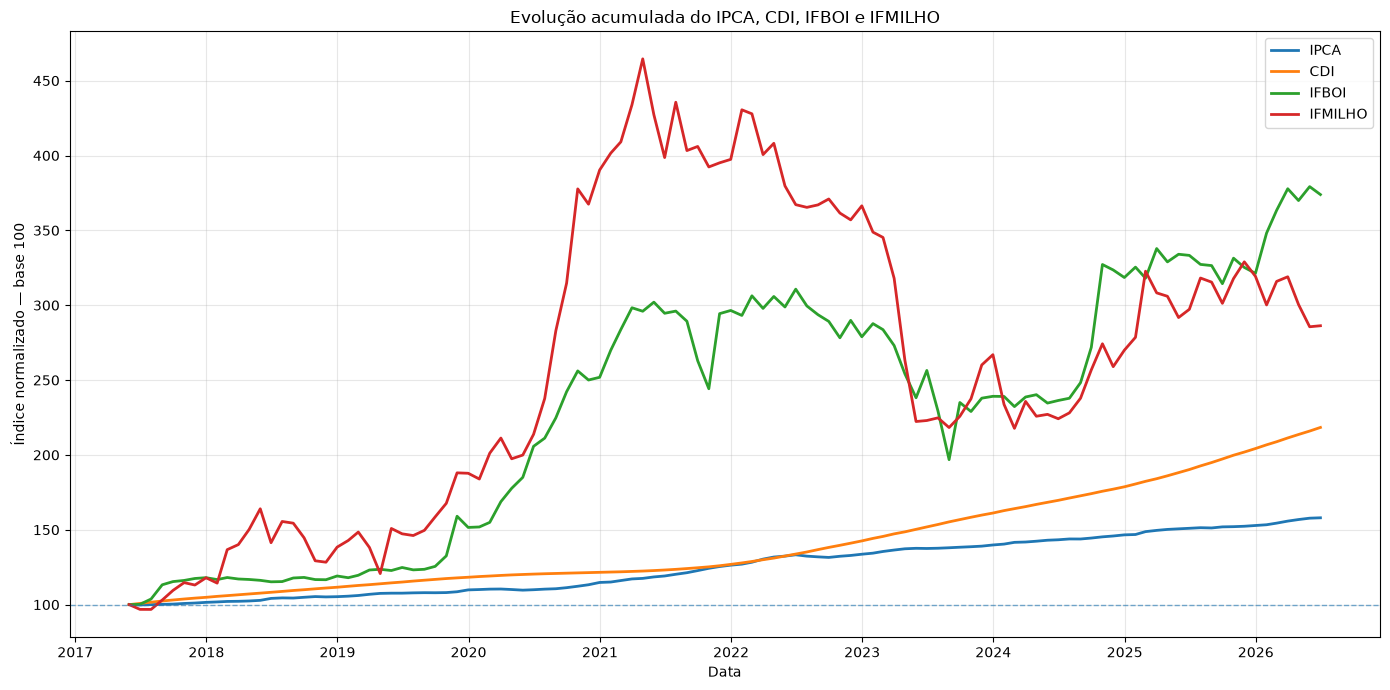

In [28]:
grafico_principal = (
    base_mensal_modelo[
        [
            "mes",
            "ipca_index",
            "cdi_index",
            "ifboi_index",
            "ifmilho_index",
        ]
    ]
    .dropna()
    .sort_values("mes")
    .reset_index(drop=True)
    .copy()
)

# Converte o período mensal em uma data para o eixo horizontal.
grafico_principal["data"] = (
    grafico_principal["mes"]
    .dt.to_timestamp(how="end")
    .dt.normalize()
)

# Normaliza todos os índices para 100 na primeira observação comum.
colunas_indices = [
    "ipca_index",
    "cdi_index",
    "ifboi_index",
    "ifmilho_index",
]

for coluna in colunas_indices:
    grafico_principal[f"{coluna}_base_100"] = (
        grafico_principal[coluna]
        / grafico_principal[coluna].iloc[0]
        * 100
    )

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    grafico_principal["data"],
    grafico_principal["ipca_index_base_100"],
    label="IPCA",
    linewidth=2,
)

ax.plot(
    grafico_principal["data"],
    grafico_principal["cdi_index_base_100"],
    label="CDI",
    linewidth=2,
)

ax.plot(
    grafico_principal["data"],
    grafico_principal["ifboi_index_base_100"],
    label="IFBOI",
    linewidth=2,
)

ax.plot(
    grafico_principal["data"],
    grafico_principal["ifmilho_index_base_100"],
    label="IFMILHO",
    linewidth=2,
)

ax.axhline(
    100,
    linewidth=1,
    linestyle="--",
    alpha=0.6,
)

ax.set_title(
    "Evolução acumulada do IPCA, CDI, IFBOI e IFMILHO"
)

ax.set_xlabel("Data")
ax.set_ylabel("Índice normalizado — base 100")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpolação diária do IPCA

A Bloomberg associa cada observação mensal do `BZPIIPCA Index` ao último dia do respectivo mês de referência. Seguindo essa convenção, consideramos que o número-índice do IPCA de cada mês corresponde ao último dia daquele mês.

Como os índices de futuros de milho, boi gordo e CDI possuem frequência diária, interpolamos linearmente o número-índice do IPCA entre os finais de cada mês. Dessa forma, construímos uma aproximação diária da evolução do nível de preços, preservando integralmente os valores mensais originais.

A interpolação permite alinhar todas as séries na mesma frequência e calcular retornos diários sincronizados para IPCA, CDI, IFBOI e IFMILHO.

In [32]:
ipca_fim_mes = (
    ipca[
        [
            "periodo_referencia",
            "ipca_index",
        ]
    ]
    .copy()
)

# Converte o período de referência para o último dia
# do respectivo mês.
ipca_fim_mes["data"] = (
    pd.PeriodIndex(
        ipca_fim_mes["periodo_referencia"],
        freq="M",
    )
    .to_timestamp(how="end")
    .normalize()
)

ipca_fim_mes = (
    ipca_fim_mes[
        [
            "data",
            "ipca_index",
        ]
    ]
    .drop_duplicates(subset="data")
    .sort_values("data")
    .reset_index(drop=True)
)

ipca_fim_mes.head()

,data,ipca_index
0,2017-04-30,4828.44
1,2017-05-31,4843.41
2,2017-06-30,4832.27
3,2017-07-31,4843.87
4,2017-08-31,4853.07


In [33]:
ipca_diario = (
    ipca_fim_mes
    .set_index("data")
    .resample("D")
    .asfreq()
)

ipca_diario["ipca_index"] = (
    ipca_diario["ipca_index"]
    .interpolate(method="time")
)

ipca_diario = (
    ipca_diario
    .reset_index()
)

ipca_diario.head()

,data,ipca_index
0,2017-04-30,4828.440000
1,2017-05-01,4828.922903
2,2017-05-02,4829.405806
3,2017-05-03,4829.888710
4,2017-05-04,4830.371613


In [36]:
cdi_diario = (
    cdi[
        [
            "data",
            "cdi_index",
        ]
    ]
    .copy()
)

cdi_diario["data"] = pd.to_datetime(
    cdi_diario["data"]
)

cdi_diario = (
    cdi_diario
    .dropna()
    .drop_duplicates(subset="data")
    .sort_values("data")
    .reset_index(drop=True)
)

base_diaria = (
    commodities_diario
    .merge(
        cdi_diario,
        on="data",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        ipca_diario,
        on="data",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("data")
    .reset_index(drop=True)
)

base_diaria.head()

,data,ifboi_index,ifmilho_index,cdi_index,ipca_index
0,2017-05-02,1010.790610,994.894041,234159.3,4829.405806
1,2017-05-03,1006.423984,992.685267,234257.4,4829.888710
2,2017-05-04,1001.822936,992.459451,234355.5,4830.371613
3,2017-05-05,1000.106302,993.727655,234453.7,4830.854516
4,2017-05-08,1002.812860,985.916340,234551.9,4832.303226


In [37]:
base_diaria["inflacao_diaria_interpolada"] = (
    base_diaria["ipca_index"]
    .pct_change()
)

base_diaria["retorno_ifboi_diario"] = (
    base_diaria["ifboi_index"]
    .pct_change()
)

base_diaria["retorno_ifmilho_diario"] = (
    base_diaria["ifmilho_index"]
    .pct_change()
)

base_diaria["retorno_cdi_diario"] = (
    base_diaria["cdi_index"]
    .pct_change()
)

base_diaria_modelo = (
    base_diaria
    .dropna(
        subset=[
            "inflacao_diaria_interpolada",
            "retorno_ifboi_diario",
            "retorno_ifmilho_diario",
            "retorno_cdi_diario",
        ]
    )
    .reset_index(drop=True)
)

base_diaria_modelo.head()

,data,ifboi_index,ifmilho_index,cdi_index,ipca_index,inflacao_diaria_interpolada,retorno_ifboi_diario,retorno_ifmilho_diario,retorno_cdi_diario
0,2017-05-03,1006.423984,992.685267,234257.4,4829.888710,0.0001,-0.004320,-0.002220,0.000419
1,2017-05-04,1001.822936,992.459451,234355.5,4830.371613,0.0001,-0.004572,-0.000227,0.000419
2,2017-05-05,1000.106302,993.727655,234453.7,4830.854516,0.0001,-0.001714,0.001278,0.000419
3,2017-05-08,1002.812860,985.916340,234551.9,4832.303226,0.0003,0.002706,-0.007861,0.000419
4,2017-05-09,1003.162631,980.959054,234650.1,4832.786129,0.0001,0.000349,-0.005028,0.000419


In [38]:
grafico_diario = base_diaria.copy()

colunas_indices = [
    "ipca_index",
    "cdi_index",
    "ifboi_index",
    "ifmilho_index",
]

for coluna in colunas_indices:
    grafico_diario[f"{coluna}_base_100"] = (
        grafico_diario[coluna]
        / grafico_diario[coluna].iloc[0]
        * 100
    )

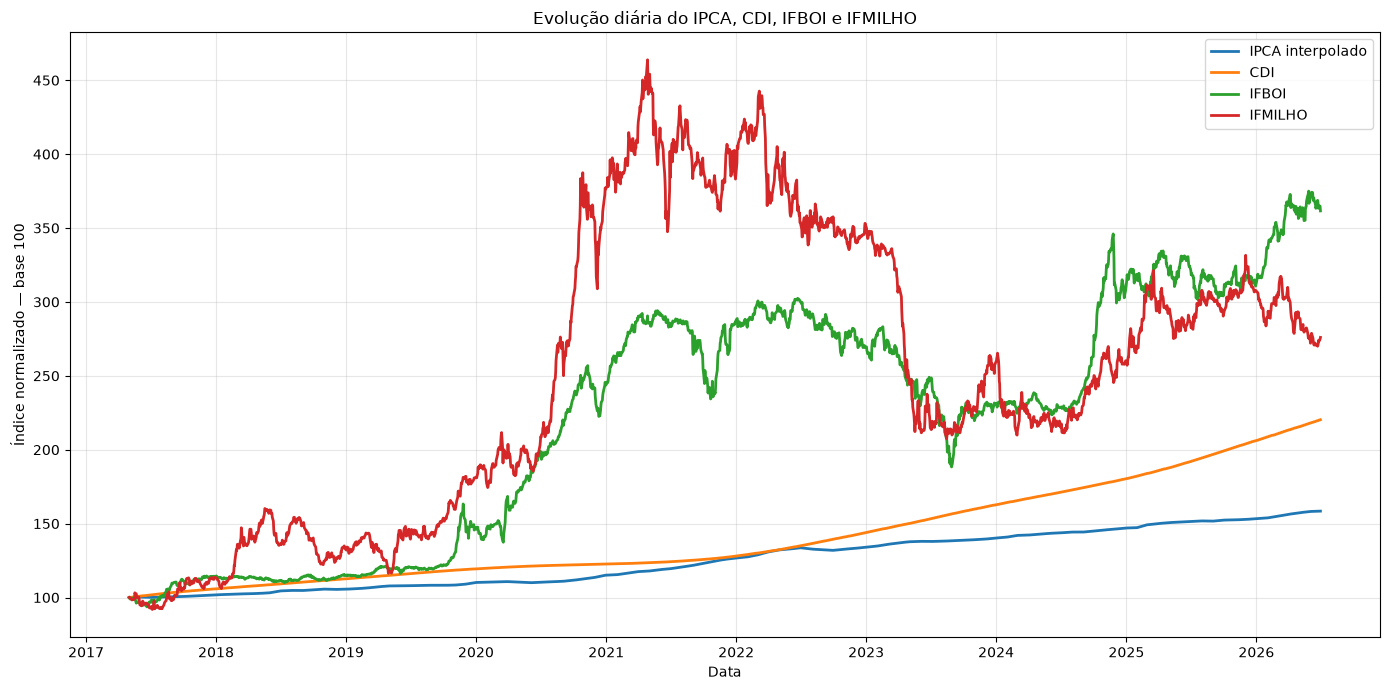

In [39]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    grafico_diario["data"],
    grafico_diario["ipca_index_base_100"],
    label="IPCA interpolado",
    linewidth=2,
)

ax.plot(
    grafico_diario["data"],
    grafico_diario["cdi_index_base_100"],
    label="CDI",
    linewidth=2,
)

ax.plot(
    grafico_diario["data"],
    grafico_diario["ifboi_index_base_100"],
    label="IFBOI",
    linewidth=2,
)

ax.plot(
    grafico_diario["data"],
    grafico_diario["ifmilho_index_base_100"],
    label="IFMILHO",
    linewidth=2,
)

ax.set_title(
    "Evolução diária do IPCA, CDI, IFBOI e IFMILHO"
)

ax.set_xlabel("Data")
ax.set_ylabel("Índice normalizado — base 100")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
matriz_correlacao_diaria = (
    base_diaria_modelo[
        [
            "inflacao_diaria_interpolada",
            "retorno_ifboi_diario",
            "retorno_ifmilho_diario",
            "retorno_cdi_diario",
        ]
    ]
    .corr()
    .rename(
        index={
            "inflacao_diaria_interpolada": "IPCA",
            "retorno_ifboi_diario": "IFBOI",
            "retorno_ifmilho_diario": "IFMILHO",
            "retorno_cdi_diario": "CDI",
        },
        columns={
            "inflacao_diaria_interpolada": "IPCA",
            "retorno_ifboi_diario": "IFBOI",
            "retorno_ifmilho_diario": "IFMILHO",
            "retorno_cdi_diario": "CDI",
        },
    )
)

matriz_correlacao_diaria.round(4)

,IPCA,IFBOI,IFMILHO,CDI
IPCA,1.0000,0.0361,0.0204,-0.0620
IFBOI,0.0361,1.0000,0.1306,-0.0564
IFMILHO,0.0204,0.1306,1.0000,-0.0770
CDI,-0.0620,-0.0564,-0.0770,1.0000


In [41]:
correlacoes_ipca_diarias = pd.DataFrame(
    {
        "ativo": [
            "IFBOI",
            "IFMILHO",
            "CDI",
        ],
        "correlacao_com_ipca": [
            base_diaria_modelo[
                "retorno_ifboi_diario"
            ].corr(
                base_diaria_modelo[
                    "inflacao_diaria_interpolada"
                ]
            ),
            base_diaria_modelo[
                "retorno_ifmilho_diario"
            ].corr(
                base_diaria_modelo[
                    "inflacao_diaria_interpolada"
                ]
            ),
            base_diaria_modelo[
                "retorno_cdi_diario"
            ].corr(
                base_diaria_modelo[
                    "inflacao_diaria_interpolada"
                ]
            ),
        ],
    }
)

correlacoes_ipca_diarias.round(4)

,ativo,correlacao_com_ipca
0,IFBOI,0.0361
1,IFMILHO,0.0204
2,CDI,-0.0620


In [42]:
import statsmodels.api as sm


def regressao_fisher_diaria(
    dados,
    coluna_retorno,
    nome_ativo,
):
    y = (
        dados[coluna_retorno]
        * 100
    )

    X = pd.DataFrame(
        {
            "inflacao": (
                dados[
                    "inflacao_diaria_interpolada"
                ]
                * 100
            )
        }
    )

    X = sm.add_constant(X)

    modelo = sm.OLS(
        y,
        X,
        missing="drop",
    ).fit(
        cov_type="HC0"
    )

    intervalo = modelo.conf_int().loc[
        "inflacao"
    ]

    return {
        "ativo": nome_ativo,
        "alpha": modelo.params["const"],
        "beta_fisher": modelo.params["inflacao"],
        "erro_padrao_robusto": modelo.bse["inflacao"],
        "estatistica_t": modelo.tvalues["inflacao"],
        "p_valor": modelo.pvalues["inflacao"],
        "limite_inferior_95": intervalo.iloc[0],
        "limite_superior_95": intervalo.iloc[1],
        "r_quadrado": modelo.rsquared,
        "observacoes": modelo.nobs,
    }

In [43]:
resultados_fisher_diarios = pd.DataFrame(
    [
        regressao_fisher_diaria(
            base_diaria_modelo,
            "retorno_ifboi_diario",
            "IFBOI",
        ),
        regressao_fisher_diaria(
            base_diaria_modelo,
            "retorno_ifmilho_diario",
            "IFMILHO",
        ),
    ]
)

resultados_fisher_diarios.round(4)

,ativo,alpha,beta_fisher,erro_padrao_robusto,estatistica_t,p_valor,limite_inferior_95,limite_superior_95,r_quadrado,observacoes
0,IFBOI,0.0360,1.1937,0.9018,1.3237,0.1856,-0.5738,2.9612,0.0013,2275.0
1,IFMILHO,0.0322,1.0369,1.1725,0.8843,0.3765,-1.2612,3.3350,0.0004,2275.0


### Resultados com o IPCA interpolado

Após a interpolação diária do IPCA, as correlações com os retornos do IFBOI e do IFMILHO tornaram-se positivas, assumindo valores de 0,0361 e 0,0204, respectivamente. Apesar da mudança de sinal em relação aos resultados mensais, as correlações permanecem muito próximas de zero.

Os coeficientes de Fisher foram de 1,1937 para o IFBOI e 1,0369 para o IFMILHO. Entretanto, nenhum deles foi estatisticamente significativo. Os p-valores foram de 0,1856 e 0,3765, e ambos os intervalos de confiança de 95% incluíram zero. O poder explicativo das regressões também permaneceu praticamente nulo.

Assim, a análise diária interpolada não fornece evidência estatística de que IFBOI ou IFMILHO tenham funcionado como hedge contra a inflação. O aumento no número de observações decorre da interpolação de uma série originalmente mensal, não da inclusão de novas divulgações independentes de inflação.

A correlação diária entre CDI e IPCA foi negativa, em −0,0620. Esse resultado não implica inconsistência, pois o retorno do CDI não reage simultaneamente à inflação. A política monetária responde à inflação e às expectativas com defasagens, podendo haver períodos em que a inflação aumenta enquanto o CDI ainda está baixo e períodos em que o CDI permanece alto enquanto a inflação desacelera.